# 01 CNN Architecture

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a small CNN with convolutional and pooling layers
- Train it on MNIST and see loss/accuracy
- Understand why we use conv layers instead of a plain MLP for images

---

## 🌍 Real life

**Where is this used?** CNNs are used for **image classification**, **object detection**, **medical imaging**, and **face recognition**.

**In this notebook we use** a **CNN** (conv + pooling + dense) to **classify handwritten digits**. We use **convolutional layers** (instead of a plain MLP that flattens the image) **because** images have **spatial structure**; conv layers preserve where features are and learn local patterns (edges, textures).

**📌 Covers slide(s):** **05** — CNN Architecture (conv, pooling, fully connected). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Convolution:** Small filters slide over the image; each filter detects a local pattern (e.g. edge). Output is a feature map.
- **Pooling (e.g. MaxPool):** Reduces spatial size; keeps the strongest activation in each region; adds translation invariance.
- **Typical block:** Conv → activation (ReLU) → Pooling. After several blocks: Flatten → Dense → output.
- **We use CNN** instead of MLP on flattened pixels because conv layers use spatial structure; an MLP would lose "where" things are.

## 📥 Inputs & 📤 Outputs

**Inputs:** MNIST (28×28 grayscale), TensorFlow/Keras, NumPy, Matplotlib. We use a subset or few epochs so it runs in ~10 min.

**Dataset:** Real — MNIST (handwritten digits).

**Outputs:** Training/validation loss and accuracy curves (with axis labels), test accuracy, and a few sample predictions (true → predicted).

**Expected:** Loss should decrease and accuracy increase; test accuracy typically >0.95 on MNIST with a few epochs. Sample predictions should match most true labels.

## Step 1: Imports and load MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train[..., np.newaxis]
    x_test = x_test[..., np.newaxis]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


## Step 2: Build CNN (we use Conv2D + MaxPool instead of only Dense to use spatial structure)

In [2]:
if HAS_TF:
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (3 epochs so it runs in ~2–5 min)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_split=0.1, epochs=3, batch_size=128, verbose=1)

Epoch 1/3


  1/422 ━━━━━━━━━━━━━━━━━━━━ 2:26 348ms/step - accuracy: 0.1328 - loss: 2.2955

  7/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2209 - loss: 2.2242   

 13/422 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2896 - loss: 2.1300

 19/422 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3559 - loss: 2.0083

...

403/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9849 - loss: 0.0470

409/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9849 - loss: 0.0470

415/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9849 - loss: 0.0469

420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9850 - loss: 0.0469

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9857 - loss: 0.0457 - val_accuracy: 0.9862 - val_loss: 0.0466


## Step 4: Plot loss and accuracy

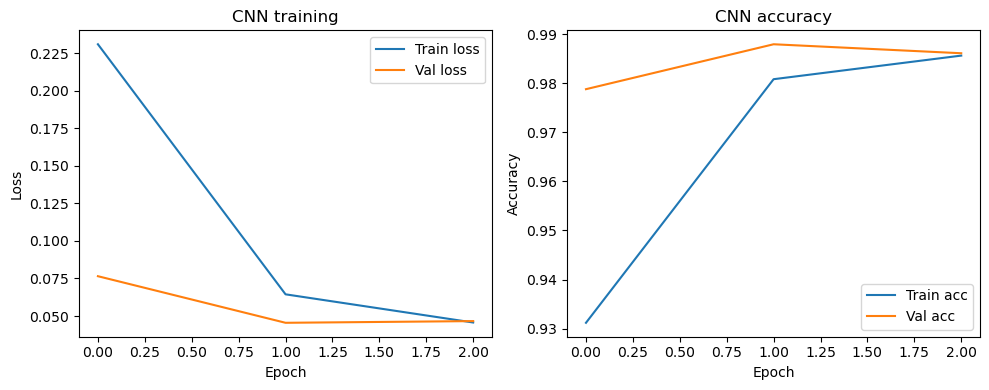

In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("CNN training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("CNN accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()

## Step 5: Evaluate and sample predictions

In [5]:
if HAS_TF:
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % test_acc)
    preds = np.argmax(model.predict(x_test[:5]), axis=1)
    print("Sample predictions (true → predicted):", list(zip(y_test[:5].tolist(), preds.tolist())))

Test accuracy: 0.9854
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


Sample predictions (true → predicted): [(7, 7), (2, 2), (1, 1), (0, 0), (4, 4)]


## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

plt.plot(losses); plt.title("CIFAR-10 Training Loss (Real Images)"); plt.xlabel("Epoch")
plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it (choose one):** Add one more Conv2D layer (e.g. 64 filters) before the Flatten layer, then retrain for 2 epochs. Does accuracy improve? Or change the number of filters in the first Conv2D (e.g. 16 → 32) and compare.

---

## ✅ Summary

**What you did:** Built a CNN (Conv2D, MaxPool, Dense), trained on MNIST, and plotted loss/accuracy and sample predictions.

**In real life you'd also:** Use data augmentation, more epochs, and tune filter sizes and depths.

**The main idea:** CNNs use convolutional and pooling layers to exploit spatial structure in images; they typically outperform an MLP on raw pixels.

**Next:** `03_cnn_advanced_architectures` introduces ResNet-style models; `05_transfer_learning_cnns` uses pre-trained models.

## 📚 References & Further Reading

**Key Papers:**
- LeCun et al. (1998) — [LeNet](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf)
- Krizhevsky et al. (2012) — [AlexNet](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)
- He et al. (2016) — [ResNet: Deep Residual Learning](https://arxiv.org/abs/1512.03385)

**torchvision Models:** [torchvision.models](https://pytorch.org/vision/stable/models.html)

**State-of-the-Art (2025):** EfficientNetV2, ConvNeXt V2, and ViT-G/14 achieve 90%+ on ImageNet.